In [ ]:
!pip install ultralytics --quiet

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.2/1.2 MB 69.7 MB/s eta 0:00:00


In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
import torch
print("GPU available:", torch.cuda.is_available())

GPU available: True


In [ ]:
IMAGE_DIR ='/content/drive/MyDrive/assignment /Pictures'

In [ ]:
import os

base = "/content/dataset_cls"

classes = ["sky", "road", "flower", "nature"]

for split in ["train", "val"]:
    for c in classes:
        os.makedirs(f"{base}/{split}/{c}", exist_ok=True)

print("Folders created")

Folders created


In [ ]:
import os
import random
import shutil

images = [
    f for f in os.listdir(IMAGE_DIR)
    if f.lower().endswith((".jpg", ".png", ".jpeg"))
]

random.shuffle(images)

split = int(0.8 * len(images))
train_images = images[:split]
val_images = images[split:]

classes = ["sky", "road", "flower", "nature"]

# TRAIN
for i, img in enumerate(train_images):
    cls = classes[i % len(classes)]
    shutil.copy(
        os.path.join(IMAGE_DIR, img),
        f"/content/dataset_cls/train/{cls}/{img}"
    )

# VAL
for i, img in enumerate(val_images):
    cls = classes[i % len(classes)]
    shutil.copy(
        os.path.join(IMAGE_DIR, img),
        f"/content/dataset_cls/val/{cls}/{img}"
    )

print("Dataset ready")

Dataset ready


In [ ]:
for split in ["train", "val"]:
    print("\n", split)
    for c in classes:
        path = f"/content/dataset_cls/{split}/{c}"
        print(c, ":", len(os.listdir(path)))


 train
sky : 32
road : 32
flower : 32
nature : 32

 val
sky : 8
road : 8
flower : 8
nature : 8


In [ ]:
from ultralytics import YOLO

model = YOLO("yolov8n-cls.pt")

model.train(
    data="/content/dataset_cls",
    epochs=30,
    imgsz=224,
    batch=16
)

Creating new Ultralytics Settings v0.0.6 file ✅ 
View Ultralytics Settings with 'yolo settings' or at '/root/.config/Ultralytics/settings.json'
Update Settings with 'yolo settings key=value', i.e. 'yolo settings runs_dir=path/to/dir'. For help see https://docs.ultralytics.com/quickstart/#ultralytics-settings.
Ultralytics 8.4.51 🚀 Python-3.12.13 torch-2.10.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
engine/trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=16, bgr=0.0, box=7.5, cache=False, cfg=None, classes=None, close_mosaic=10, cls=0.5, cls_pw=0.0, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=/content/dataset_cls, degrees=0.0, deterministic=True, device=None, dfl=1.5, dnn=False, dropout=0.0, dynamic=False, embed=None, end2end=None, epochs=30, erasing=0.4, exist_ok=False, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, half=False, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=224,

ultralytics.utils.metrics.ClassifyMetrics object with attributes:

confusion_matrix: <ultralytics.utils.metrics.ConfusionMatrix object at 0x79644c582c30>
curves: []
curves_results: []
fitness: 0.671875
keys: ['metrics/accuracy_top1', 'metrics/accuracy_top5']
results_dict: {'metrics/accuracy_top1': 0.34375, 'metrics/accuracy_top5': 1.0, 'fitness': 0.671875}
save_dir: PosixPath('/content/runs/classify/train')
speed: {'preprocess': 0.09606384375615562, 'inference': 0.4293513124906667, 'loss': 0.00027609374342318915, 'postprocess': 0.00036278125037370046}
top1: 0.34375
top5: 1.0

In [ ]:
metrics = model.val()
print(metrics)

Ultralytics 8.4.51 🚀 Python-3.12.13 torch-2.10.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
YOLOv8n-cls summary (fused): 30 layers, 1,440,004 parameters, 0 gradients, 3.3 GFLOPs
train: /content/dataset_cls/train... found 128 images in 4 classes ✅ 
val: /content/dataset_cls/val... found 32 images in 4 classes ✅ 
test: None...
val: Fast image access ✅ (ping: 0.0±0.0 ms, read: 2270.0±1677.2 MB/s, size: 2953.4 KB)
val: Scanning /content/dataset_cls/val... 32 images, 0 corrupt: 100% ━━━━━━━━━━━━ 32/32 10.3Mit/s 0.0s
               classes   top1_acc   top5_acc: 100% ━━━━━━━━━━━━ 2/2 6.9s/it 13.7s
                   all      0.344          1
Speed: 0.4ms preprocess, 2.8ms inference, 0.0ms loss, 0.0ms postprocess per image
Results saved to /content/runs/classify/val
ultralytics.utils.metrics.ClassifyMetrics object with attributes:

confusion_matrix: <ultralytics.utils.metrics.ConfusionMatrix object at 0x79640b42f0b0>
curves: []
curves_results: []
fitness: 0.671875
keys: ['metrics/accuracy_top1', 'metr

In [ ]:
import os

results = model.predict(
    source=os.path.join(IMAGE_DIR, "IMG_20230824_164621.jpg"),
    save=True
)

print(results)


image 1/1 /content/drive/MyDrive/assignment /Pictures/IMG_20230824_164621.jpg: 224x224 sky 0.96, nature 0.03, flower 0.01, road 0.01, 3.9ms
Speed: 204.0ms preprocess, 3.9ms inference, 0.1ms postprocess per image at shape (1, 3, 224, 224)
Results saved to /content/runs/classify/predict
[ultralytics.engine.results.Results object with attributes:

boxes: None
keypoints: None
masks: None
names: {0: 'flower', 1: 'nature', 2: 'road', 3: 'sky'}
obb: None
orig_img: array([[[255, 240, 241],
        [255, 240, 241],
        [254, 238, 239],
        ...,
        [255, 255, 255],
        [255, 255, 255],
        [255, 255, 255]],

       [[254, 238, 239],
        [255, 239, 240],
        [254, 238, 239],
        ...,
        [255, 255, 255],
        [255, 255, 255],
        [255, 255, 255]],

       [[255, 239, 240],
        [255, 239, 240],
        [254, 238, 239],
        ...,
        [255, 255, 255],
        [255, 255, 255],
        [255, 255, 255]],

       ...,

       [[ 17,  57,  46],
    

In [ ]:
r = results[0]

print("Top class:", r.names[r.probs.top1])
print("Confidence:", r.probs.top1conf)

Top class: sky
Confidence: tensor(0.9580, device='cuda:0')


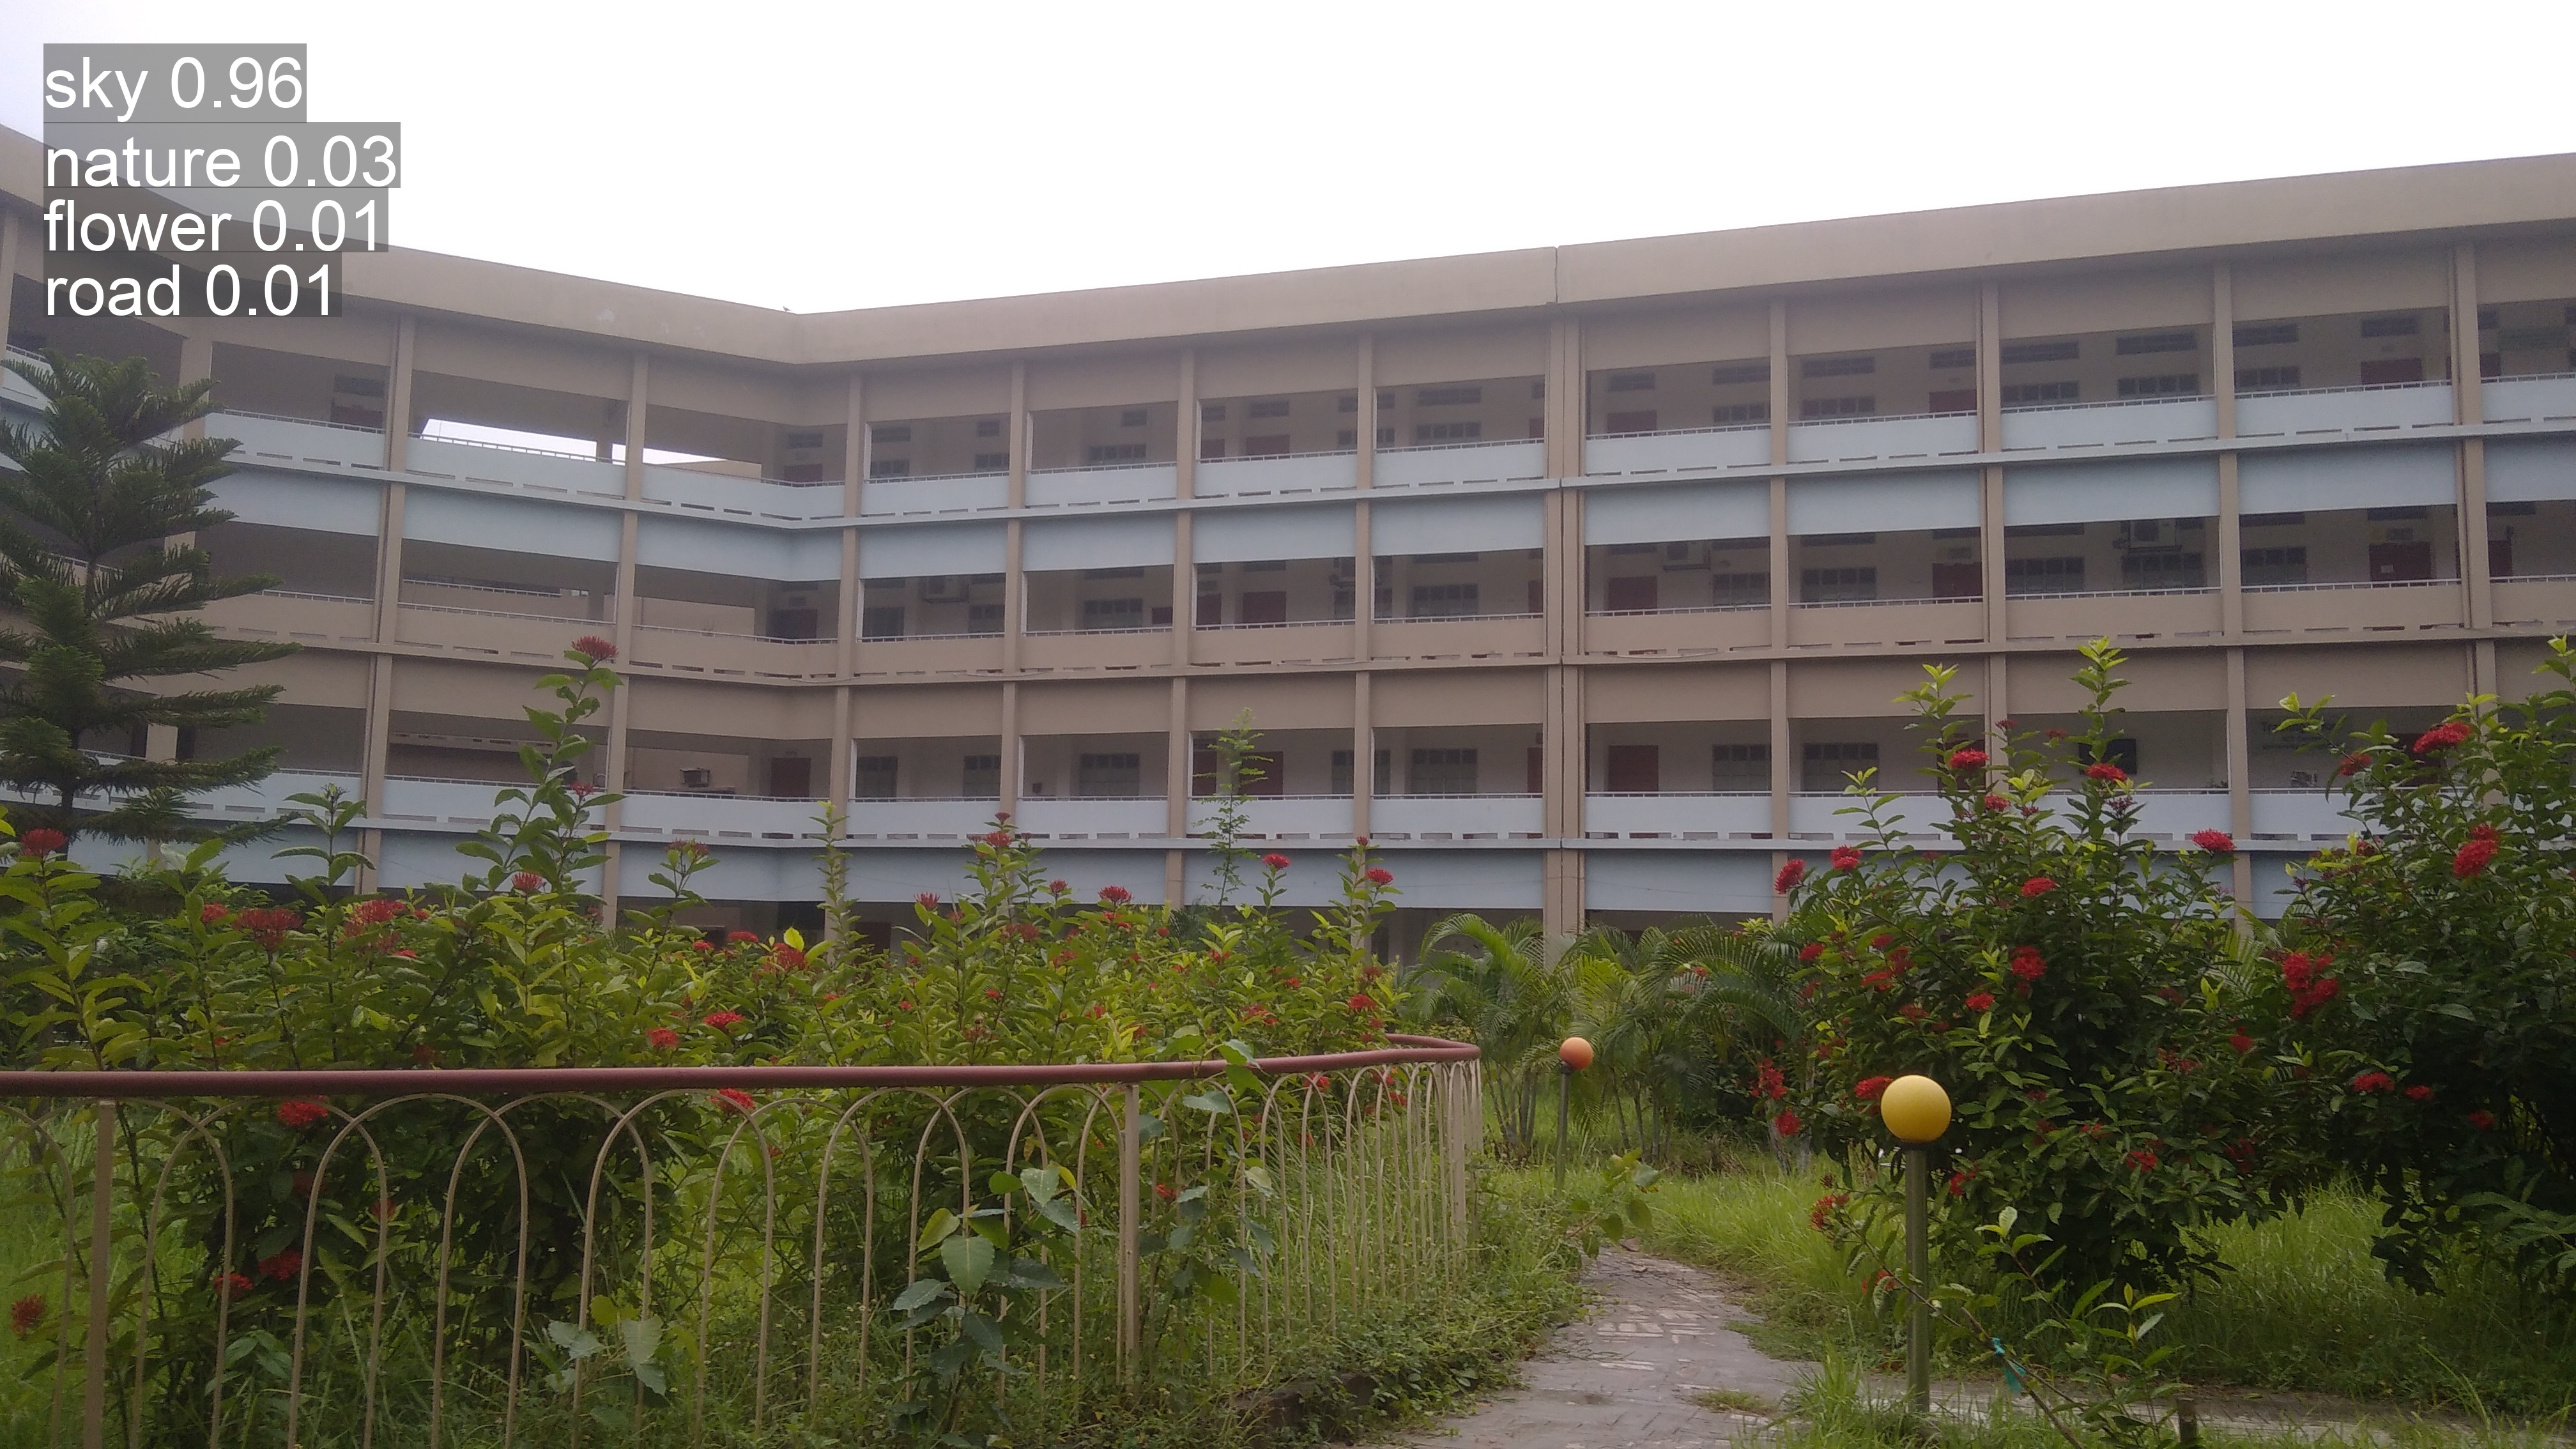

In [ ]:
from IPython.display import Image

Image("/content/runs/classify/predict/IMG_20230824_164621.jpg")